# Preprocesamiento de Datos - Clustering de Usuarios

Este notebook realiza la **transformación del dataset de transacciones a dataset de usuarios** para el proyecto de clustering.

## Objetivos del preprocesamiento:

1. **Feature Engineering**: Generar variables RFM (Recency, Frequency, Monetary) y comportamiento
2. **Limpieza de outliers**: Detectar y eliminar/ajustar usuarios anómalos con Isolation Forest
3. **Escalado**: Normalizar features con RobustScaler (resistente a outliers)
4. **Encoding**: Codificar variables categóricas con One-Hot Encoding
5. **Reducción de dimensionalidad**: Aplicar PCA manteniendo ≥60% varianza explicada

## Dataset de entrada:
- **Archivo**: `data/interim/interim_ProyClustering/data_sanitized.csv`
- **Estructura**: Dataset de transacciones limpio (1 fila = 1 transacción)
- **Características**: 0 nulos, 0 duplicados, outliers capados, cancelaciones conservadas

## Dataset de salida:
- **Archivo**: `data/processed/data_clustering_pca.csv`
- **Estructura**: Dataset de usuarios (1 fila = 1 usuario/CustomerID)
- **Características**: Features escaladas, reducidas con PCA, listas para clustering

---
## 0. Imports, Configuración y Carga del Dataset Limpio

Preparamos el entorno de trabajo:
- Importamos todas las librerías necesarias para preprocesamiento y clustering
- Configuramos la estética visual global
- Definimos las rutas del proyecto
- Cargamos el dataset limpio de transacciones
- Verificamos que el dataset está correcto (dimensiones, nulos, duplicados)

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# 0. IMPORTS Y CONFIGURACIÓN
# ══════════════════════════════════════════════════════════════════════════════

# ── Librerías básicas ─────────────────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualización ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# ── Preprocesamiento y escalado ───────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# ── Reducción de dimensionalidad ──────────────────────────────────────────────
from sklearn.decomposition import PCA

# ── Detección de anomalías ────────────────────────────────────────────────────
from sklearn.ensemble import IsolationForest

# ── Persistencia de modelos ───────────────────────────────────────────────────
import joblib

# ── Configuración visual global ───────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10
%matplotlib inline

# ── Configuración de pandas ───────────────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print('[OK] Librerías importadas correctamente')
print(f'\nVersiones:')
print(f'   - pandas: {pd.__version__}')
print(f'   - numpy: {np.__version__}')
print(f'   - matplotlib: {plt.matplotlib.__version__}')
print(f'   - seaborn: {sns.__version__}')

[OK] Librerías importadas correctamente

Versiones:
   - pandas: 3.0.2
   - numpy: 2.4.4
   - matplotlib: 3.10.8
   - seaborn: 0.13.2


In [13]:
# ── Rutas del proyecto ───────────────────────────────────────────────────────

# Ruta del dataset limpio (input)
RUTA_DATA_LIMPIA = '../../../data/interim/interim_ProyClustering/data_sanitized.csv'

# Rutas de salida
RUTA_PROCESSED = '../../../data/processed/'
RUTA_GRAFICOS  = '../../../graphics/gr_clustering/preprocesing/'
RUTA_MODELS    = '../../../models/'

# Crear directorios si no existen
os.makedirs(RUTA_PROCESSED, exist_ok=True)
os.makedirs(RUTA_GRAFICOS, exist_ok=True)
os.makedirs(RUTA_MODELS, exist_ok=True)

print('[OK] Rutas configuradas correctamente')
print(f'\nEstructura de directorios:')
print(f'   Input:')
print(f'   - Dataset limpio      : {RUTA_DATA_LIMPIA}')
print(f'\n   Output:')
print(f'   - Datos procesados    : {RUTA_PROCESSED}')
print(f'   - Gráficos            : {RUTA_GRAFICOS}')
print(f'   - Modelos (scalers)   : {RUTA_MODELS}')

[OK] Rutas configuradas correctamente

Estructura de directorios:
   Input:
   - Dataset limpio      : ../../../data/interim/interim_ProyClustering/data_sanitized.csv

   Output:
   - Datos procesados    : ../../../data/processed/
   - Gráficos            : ../../../graphics/gr_clustering/preprocesing/
   - Modelos (scalers)   : ../../../models/


In [14]:
# ── Carga del dataset limpio ─────────────────────────────────────────────────

print('='*80)
print('  CARGA DEL DATASET LIMPIO')
print('='*80)
print()
print(f'Cargando desde: {RUTA_DATA_LIMPIA}')
print()

# Cargar el dataset
df_transacciones = pd.read_csv(RUTA_DATA_LIMPIA)

# Convertir columnas de fecha a datetime
df_transacciones['InvoiceDate'] = pd.to_datetime(df_transacciones['InvoiceDate'])
df_transacciones['Fecha'] = pd.to_datetime(df_transacciones['Fecha'])
df_transacciones['Mes'] = df_transacciones['Mes'].astype(str)

print(f'[OK] Dataset cargado correctamente')
print()
print(f'{'─'*80}')
print(f'  DIMENSIONES DEL DATASET')
print(f'{'─'*80}')
print(f'  Filas (transacciones)     : {len(df_transacciones):>15,}')
print(f'  Columnas                  : {len(df_transacciones.columns):>15}')
print(f'  Tamaño en memoria         : {df_transacciones.memory_usage(deep=True).sum() / 1024**2:>15,.2f} MB')
print(f'{'─'*80}')
print()
print(f'  COLUMNAS DISPONIBLES ({len(df_transacciones.columns)}):')
for i, col in enumerate(df_transacciones.columns, 1):
    dtype = str(df_transacciones[col].dtype)
    print(f'    {i:>2}. {col:<20} ({dtype})')
print()
print('='*80)

  CARGA DEL DATASET LIMPIO

Cargando desde: ../../../data/interim/interim_ProyClustering/data_sanitized.csv

[OK] Dataset cargado correctamente

────────────────────────────────────────────────────────────────────────────────
  DIMENSIONES DEL DATASET
────────────────────────────────────────────────────────────────────────────────
  Filas (transacciones)     :         399,651
  Columnas                  :              13
  Tamaño en memoria         :          155.56 MB
────────────────────────────────────────────────────────────────────────────────

  COLUMNAS DISPONIBLES (13):
     1. InvoiceNo            (str)
     2. StockCode            (str)
     3. Description          (str)
     4. Quantity             (int64)
     5. InvoiceDate          (datetime64[us])
     6. UnitPrice            (float64)
     7. CustomerID           (float64)
     8. Country              (str)
     9. Fecha                (datetime64[us])
    10. Mes                  (str)
    11. DiaSemana            (str

In [15]:
# ── Verificación de calidad del dataset ──────────────────────────────────────

print('='*80)
print('  VERIFICACIÓN DE CALIDAD DEL DATASET')
print('='*80)
print()

# ── Verificación 1: Valores nulos ─────────────────────────────────────────────
nulos_total = df_transacciones.isnull().sum().sum()
nulos_por_columna = df_transacciones.isnull().sum()

print(f'  ✓ VERIFICACIÓN 1: VALORES NULOS')
print(f'  {'─'*78}')
print(f'     Total valores nulos       : {nulos_total:>10,}')
if nulos_total > 0:
    print(f'     [!] ATENCIÓN: Hay valores nulos en el dataset')
    print(f'\n     Columnas con nulos:')
    for col, count in nulos_por_columna[nulos_por_columna > 0].items():
        pct = (count / len(df_transacciones) * 100)
        print(f'       - {col:<20} : {count:>8,} ({pct:>6.2f}%)')
else:
    print(f'     [OK] No hay valores nulos')
print()

# ── Verificación 2: Duplicados ────────────────────────────────────────────────
duplicados = df_transacciones.duplicated().sum()

print(f'  ✓ VERIFICACIÓN 2: DUPLICADOS EXACTOS')
print(f'  {'─'*78}')
print(f'     Filas duplicadas          : {duplicados:>10,}')
if duplicados > 0:
    print(f'     [!] ATENCIÓN: Hay {duplicados:,} filas duplicadas')
else:
    print(f'     [OK] No hay duplicados')
print()

# ── Verificación 3: CustomerID únicos ─────────────────────────────────────────
num_usuarios = df_transacciones['CustomerID'].nunique()
customerid_nulos = df_transacciones['CustomerID'].isnull().sum()

print(f'  ✓ VERIFICACIÓN 3: CUSTOMERID (crítico para clustering)')
print(f'  {'─'*78}')
print(f'     Usuarios únicos (CustomerID) : {num_usuarios:>10,}')
print(f'     CustomerID nulos             : {customerid_nulos:>10,}')
if customerid_nulos > 0:
    print(f'     [ERROR] Hay CustomerID nulos → no se puede hacer clustering')
else:
    print(f'     [OK] Todos los registros tienen CustomerID')
print()

# ── Verificación 4: Distribución básica ───────────────────────────────────────
num_productos = df_transacciones['StockCode'].nunique()
num_facturas = df_transacciones['InvoiceNo'].nunique()
num_paises = df_transacciones['Country'].nunique()

print(f'  ✓ VERIFICACIÓN 4: ENTIDADES ÚNICAS')
print(f'  {'─'*78}')
print(f'     Usuarios (CustomerID)     : {num_usuarios:>10,}')
print(f'     Productos (StockCode)     : {num_productos:>10,}')
print(f'     Facturas (InvoiceNo)      : {num_facturas:>10,}')
print(f'     Países                    : {num_paises:>10,}')
print()

# ── Verificación 5: Rango temporal ────────────────────────────────────────────
fecha_min = df_transacciones['InvoiceDate'].min()
fecha_max = df_transacciones['InvoiceDate'].max()
dias_totales = (fecha_max - fecha_min).days

print(f'  ✓ VERIFICACIÓN 5: COBERTURA TEMPORAL')
print(f'  {'─'*78}')
print(f'     Fecha inicio              : {fecha_min.strftime("%Y-%m-%d")}')
print(f'     Fecha fin                 : {fecha_max.strftime("%Y-%m-%d")}')
print(f'     Duración                  : {dias_totales} días')
print()

# ── Resumen de validación ─────────────────────────────────────────────────────
print(f'{'='*80}')
errores = []
if nulos_total > 0:
    errores.append('Valores nulos detectados')
if duplicados > 0:
    errores.append('Duplicados detectados')
if customerid_nulos > 0:
    errores.append('CustomerID nulos (CRÍTICO)')

if len(errores) == 0:
    print(f'  [OK] DATASET VALIDADO CORRECTAMENTE')
    print(f'  {'─'*78}')
    print(f'     El dataset está limpio y listo para preprocesamiento')
    print(f'     Próximo paso: Generar features de usuario (RFM + comportamiento)')
else:
    print(f'  [ERROR] ERRORES DETECTADOS EN EL DATASET')
    print(f'  {'─'*78}')
    for error in errores:
        print(f'     • {error}')
    print(f'\n     [!] Revisar el notebook de limpieza antes de continuar')

print(f'{'='*80}')

  VERIFICACIÓN DE CALIDAD DEL DATASET

  ✓ VERIFICACIÓN 1: VALORES NULOS
  ──────────────────────────────────────────────────────────────────────────────
     Total valores nulos       :          0
     [OK] No hay valores nulos

  ✓ VERIFICACIÓN 2: DUPLICADOS EXACTOS
  ──────────────────────────────────────────────────────────────────────────────
     Filas duplicadas          :          0
     [OK] No hay duplicados

  ✓ VERIFICACIÓN 3: CUSTOMERID (crítico para clustering)
  ──────────────────────────────────────────────────────────────────────────────
     Usuarios únicos (CustomerID) :      4,362
     CustomerID nulos             :          0
     [OK] Todos los registros tienen CustomerID

  ✓ VERIFICACIÓN 4: ENTIDADES ÚNICAS
  ──────────────────────────────────────────────────────────────────────────────
     Usuarios (CustomerID)     :      4,362
     Productos (StockCode)     :      3,676
     Facturas (InvoiceNo)      :     21,785
     Países                    :         37

 

In [16]:
# ── Vista previa del dataset ─────────────────────────────────────────────────

print('\nVISTA PREVIA DEL DATASET (primeras 10 filas):')
print('='*80)
display(df_transacciones.head(10))

print('\nESTADÍSTICAS DESCRIPTIVAS (columnas numéricas):')
print('='*80)
display(df_transacciones.describe())

print('\nINFORMACIÓN DEL DATAFRAME:')
print('='*80)
df_transacciones.info()


VISTA PREVIA DEL DATASET (primeras 10 filas):


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Fecha,Mes,DiaSemana,EsCancelacion,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,20.34
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,15.30
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,25.50
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,11.10
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,11.10
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.00,United Kingdom,2010-12-01,2010-12,Wednesday,False,54.08



ESTADÍSTICAS DESCRIPTIVAS (columnas numéricas):


,Quantity,InvoiceDate,UnitPrice,CustomerID,Fecha,TotalPrice
count,399651.00,399651,399651.00,399651.00,399651,399651.00
mean,10.63,2011-07-10 12:36:01.626669,2.80,15288.78,2011-07-09 23:21:41.266354,18.53
min,-120.00,2010-12-01 08:26:00,0.03,12346.00,2010-12-01 00:00:00,-1314.00
25%,2.00,2011-04-06 15:07:00,1.25,13959.00,2011-04-06 00:00:00,4.25
50%,5.00,2011-07-29 15:51:00,1.95,15152.00,2011-07-29 00:00:00,11.56
75%,12.00,2011-10-20 12:03:00,3.75,16791.00,2011-10-20 00:00:00,19.50
max,120.00,2011-12-09 12:50:00,12.75,18287.00,2011-12-09 00:00:00,1530.00
std,18.43,NaN,2.65,1710.78,NaN,38.08



INFORMACIÓN DEL DATAFRAME:
<class 'pandas.DataFrame'>
RangeIndex: 399651 entries, 0 to 399650
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   InvoiceNo      399651 non-null  str           
 1   StockCode      399651 non-null  str           
 2   Description    399651 non-null  str           
 3   Quantity       399651 non-null  int64         
 4   InvoiceDate    399651 non-null  datetime64[us]
 5   UnitPrice      399651 non-null  float64       
 6   CustomerID     399651 non-null  float64       
 7   Country        399651 non-null  str           
 8   Fecha          399651 non-null  datetime64[us]
 9   Mes            399651 non-null  str           
 10  DiaSemana      399651 non-null  str           
 11  EsCancelacion  399651 non-null  bool          
 12  TotalPrice     399651 non-null  float64       
dtypes: bool(1), datetime64[us](2), float64(3), int64(1), str(6)
memory usage: 37.0 MB



## SIGUIENTE PASO: PASO 4 - GENERACIÓN DE FEATURES

**Objetivo**: Transformar dataset de transacciones → dataset de usuarios

En el siguiente paso crearemos:
1. **Variables RFM** (Recency, Frequency, Monetary)
2. **Variables de comportamiento** (ticket promedio, diversidad productos, gasto mensual)
3. **Variables de cancelación** (tasa devolución, ratio devuelto)
4. **Variables temporales** (día preferido, fin de semana)
5. **Variable geográfica** (país)

**Resultado esperado**: DataFrame con ~4,400 filas (1 fila por usuario) y 10-15 features

## PASO 4.1: Variables RFM (Recency, Frequency, Monetary)

**RFM** es el core del análisis de clustering en e-commerce:
- **R** (Recency): ¿Cuándo fue la última compra?
- **F** (Frequency): ¿Con qué frecuencia compra?
- **M** (Monetary): ¿Cuánto gasta en total?

---

### 4.1.A — RECENCY (Recencia)

**Definición**: Días transcurridos desde la última compra del usuario

**Interpretación**:
- Recency **bajo** (ej. 5 días) → Cliente activo, compró recientemente
- Recency **alto** (ej. 200 días) → Cliente inactivo, lleva mucho sin comprar

**Cálculo**:
```
Recency = fecha_referencia - max(InvoiceDate por usuario)
```

**Fecha de referencia**: Última fecha del dataset + 1 día  
(Simula que estamos analizando el día después del último registro)

In [17]:
# ══════════════════════════════════════════════════════════════════════════════
#   PASO 4.1.A: CÁLCULO DE RECENCY (RECENCIA)
# ══════════════════════════════════════════════════════════════════════════════

print('='*80)
print('  PASO 4.1.A: RECENCY (Recencia)')
print('='*80)
print()

# ── 1. Determinar la fecha de referencia ─────────────────────────────────────
fecha_ultima_transaccion = df_transacciones['InvoiceDate'].max()
fecha_referencia = fecha_ultima_transaccion + pd.Timedelta(days=1)

print(f'FECHAS DE REFERENCIA:')
print(f'  {'─'*78}')
print(f'     Última transacción del dataset : {fecha_ultima_transaccion.strftime("%Y-%m-%d")}')
print(f'     Fecha de referencia (+ 1 día)  : {fecha_referencia.strftime("%Y-%m-%d")}')
print()

# ── 2. Calcular la última compra por usuario ─────────────────────────────
print(f'Calculando última compra por usuario...')
ultima_compra_por_usuario = df_transacciones.groupby('CustomerID')['InvoiceDate'].max()

print(f'   [OK] Calculado para {len(ultima_compra_por_usuario):,} usuarios')
print()

# ── 3. Calcular Recency (días desde la última compra) ────────────────────────
print(f'Calculando Recency (días desde última compra)...')
recency_por_usuario = (fecha_referencia - ultima_compra_por_usuario).dt.days

print(f'   [OK] Recency calculado para {len(recency_por_usuario):,} usuarios')
print()

# ── 4. Crear DataFrame con Recency ───────────────────────────────────────────
df_rfm = pd.DataFrame({
    'CustomerID': recency_por_usuario.index,
    'Recency': recency_por_usuario.values
})

print(f'[OK] DataFrame RFM creado')
print(f'  {'─'*78}')
print(f'     Dimensiones : {df_rfm.shape[0]:,} usuarios × {df_rfm.shape[1]} columnas')
print(f'     Columnas    : {list(df_rfm.columns)}')
print()

# ── 5. Estadísticas descriptivas de Recency ──────────────────────────────
print(f'ESTADÍSTICAS DE RECENCY:')
print(f'  {'─'*78}')
print(f'     Mínimo         : {df_rfm["Recency"].min():>8} días  (usuario compró recientemente)')
print(f'     Máximo         : {df_rfm["Recency"].max():>8} días  (usuario inactivo hace tiempo)')
print(f'     Media          : {df_rfm["Recency"].mean():>8.2f} días')
print(f'     Mediana        : {df_rfm["Recency"].median():>8.0f} días')
print(f'     Desv. estándar : {df_rfm["Recency"].std():>8.2f} días')
print()

print(f'  Percentiles:')
print(f'     P25 (Q1)       : {df_rfm["Recency"].quantile(0.25):>8.0f} días')
print(f'     P50 (Mediana)  : {df_rfm["Recency"].quantile(0.50):>8.0f} días')
print(f'     P75 (Q3)       : {df_rfm["Recency"].quantile(0.75):>8.0f} días')
print(f'     P90            : {df_rfm["Recency"].quantile(0.90):>8.0f} días')
print(f'     P95            : {df_rfm["Recency"].quantile(0.95):>8.0f} días')
print(f'     P99            : {df_rfm["Recency"].quantile(0.99):>8.0f} días')

print()
print('='*80)

  PASO 4.1.A: RECENCY (Recencia)

FECHAS DE REFERENCIA:
  ──────────────────────────────────────────────────────────────────────────────
     Última transacción del dataset : 2011-12-09
     Fecha de referencia (+ 1 día)  : 2011-12-10

Calculando última compra por usuario...
   [OK] Calculado para 4,362 usuarios

Calculando Recency (días desde última compra)...
   [OK] Recency calculado para 4,362 usuarios

[OK] DataFrame RFM creado
  ──────────────────────────────────────────────────────────────────────────────
     Dimensiones : 4,362 usuarios × 2 columnas
     Columnas    : ['CustomerID', 'Recency']

ESTADÍSTICAS DE RECENCY:
  ──────────────────────────────────────────────────────────────────────────────
     Mínimo         :        1 días  (usuario compró recientemente)
     Máximo         :      374 días  (usuario inactivo hace tiempo)
     Media          :    92.17 días
     Mediana        :       50 días
     Desv. estándar :   100.97 días

  Percentiles:
     P25 (Q1)       :  

In [18]:
# ── Vista previa del DataFrame RFM (con Recency) ─────────────────────────────

print('\nVISTA PREVIA DEL DATAFRAME RFM (primeras 20 filas):')
print('='*80)
print()

# Mostrar ordenado por Recency (los más recientes primero)
print('TOP 10: Usuarios más ACTIVOS (Recency más bajo - compraron recientemente):')
display(df_rfm.nsmallest(10, 'Recency'))

print()
print('[!] TOP 10: Usuarios más INACTIVOS (Recency más alto - llevan sin comprar):')
display(df_rfm.nlargest(10, 'Recency'))

print()
print('Muestra aleatoria de 10 usuarios:')
display(df_rfm.sample(10).sort_values('Recency'))


VISTA PREVIA DEL DATAFRAME RFM (primeras 20 filas):

TOP 10: Usuarios más ACTIVOS (Recency más bajo - compraron recientemente):


,CustomerID,Recency
61,12423.00,1
71,12433.00,1
105,12476.00,1
137,12518.00,1
144,12526.00,1
259,12662.00,1
273,12680.00,1
299,12713.00,1
328,12748.00,1
475,12955.00,1



[!] TOP 10: Usuarios más INACTIVOS (Recency más alto - llevan sin comprar):


,CustomerID,Recency
357,12791.00,374
1042,13747.00,374
1760,14729.00,374
3122,16583.00,374
4086,17908.00,374
4130,17968.00,374
4202,18074.00,374
404,12855.00,373
550,13065.00,373
582,13108.00,373



Muestra aleatoria de 10 usuarios:


,CustomerID,Recency
562,13081.00,1
3106,16558.00,1
1384,14217.00,2
2469,15687.00,9
1869,14883.00,19
1488,14360.00,32
3766,17470.00,45
2411,15610.00,52
2118,15220.00,52
3127,16591.00,69



VISUALIZACIÓN: Distribución de Recency

[OK] Gráfico guardado en: ../../../graphics/gr_clustering/preprocesing/4.1.A_distribucion_recency.png


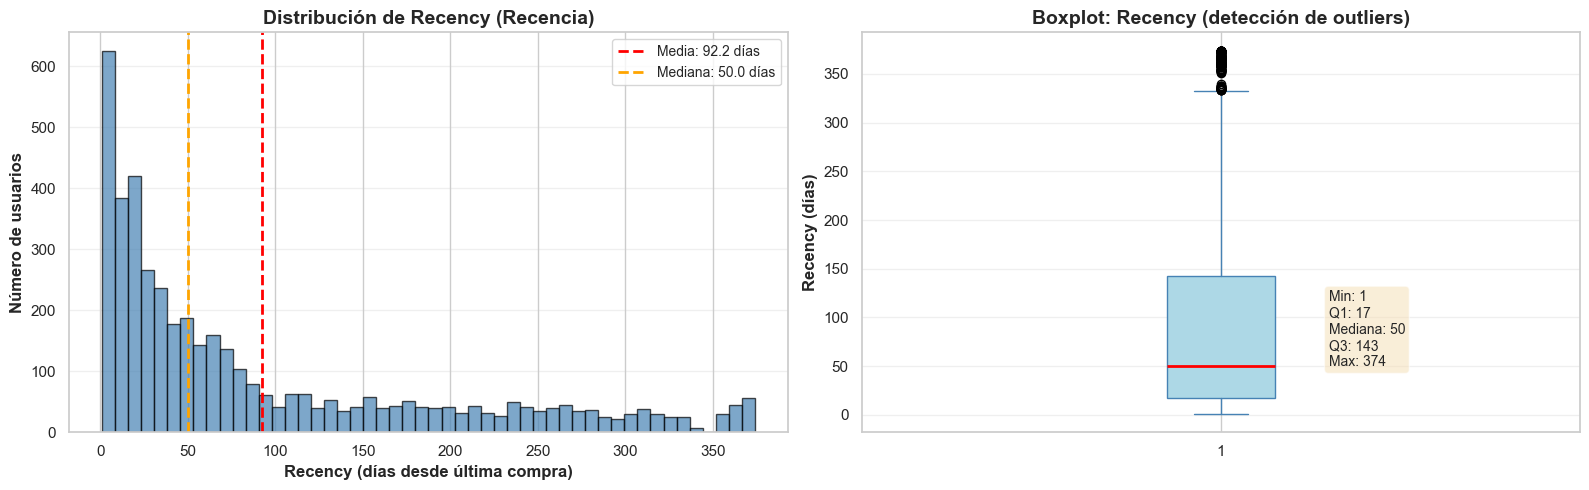

In [19]:
# ── Visualización de la distribución de Recency ──────────────────────────────

print('\nVISUALIZACIÓN: Distribución de Recency')
print('='*80)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Gráfico 1: Histograma ─────────────────────────────────────────────
axes[0].hist(df_rfm['Recency'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df_rfm['Recency'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df_rfm["Recency"].mean():.1f} días')
axes[0].axvline(df_rfm['Recency'].median(), color='orange', linestyle='--', linewidth=2, label=f'Mediana: {df_rfm["Recency"].median():.1f} días')
axes[0].set_xlabel('Recency (días desde última compra)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Número de usuarios', fontsize=12, fontweight='bold')
axes[0].set_title('Distribución de Recency (Recencia)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# ── Gráfico 2: Boxplot ────────────────────────────────────────────────────────
axes[1].boxplot(df_rfm['Recency'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='steelblue'),
                whiskerprops=dict(color='steelblue'),
                capprops=dict(color='steelblue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Recency (días)', fontsize=12, fontweight='bold')
axes[1].set_title('Boxplot: Recency (detección de outliers)', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Añadir estadísticas al boxplot
stats_text = f'Min: {df_rfm["Recency"].min():.0f}\nQ1: {df_rfm["Recency"].quantile(0.25):.0f}\nMediana: {df_rfm["Recency"].median():.0f}\nQ3: {df_rfm["Recency"].quantile(0.75):.0f}\nMax: {df_rfm["Recency"].max():.0f}'
axes[1].text(1.15, df_rfm['Recency'].median(), stats_text, fontsize=10, 
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()

# Guardar gráfico
ruta_grafico = os.path.join(RUTA_GRAFICOS, '4.1.A_distribucion_recency.png')
plt.savefig(ruta_grafico, dpi=300, bbox_inches='tight')
print(f'\n[OK] Gráfico guardado en: {ruta_grafico}')

plt.show()

print('\n' + '='*80)

---

### 4.1.B — FREQUENCY (Frecuencia)

**Definición**: Número total de transacciones (compras únicas) del usuario

**Interpretación**:
- Frequency **bajo** (ej. 1-2 compras) → Cliente ocasional, una sola compra
- Frequency **alto** (ej. 50+ compras) → Cliente frecuente/fiel, compra regularmente

**Cálculo**:
```
Frequency = count(InvoiceNo único por usuario)
```

**Nota importante**: Contamos facturas únicas (`InvoiceNo`), no líneas de transacción. Una factura puede tener múltiples productos.

**Filtro de cancelaciones**: Solo contamos facturas de compra (no cancelaciones que empiezan con 'C')

In [20]:
# ══════════════════════════════════════════════════════════════════════════════
#   PASO 4.1.B: CÁLCULO DE FREQUENCY (FRECUENCIA)
# ══════════════════════════════════════════════════════════════════════════════

print('='*80)
print('  PASO 4.1.B: FREQUENCY (Frecuencia)')
print('='*80)
print()

# ── 1. Filtrar solo transacciones de compra (sin cancelaciones) ──────────────
print(f'Filtrando transacciones...')
print(f'  {'─'*78}')

# Total de transacciones
total_transacciones = len(df_transacciones)
print(f'     Total transacciones (todas)       : {total_transacciones:>10,}')

# Filtrar cancelaciones (InvoiceNo que NO empiezan con 'C')
df_compras = df_transacciones[~df_transacciones['InvoiceNo'].astype(str).str.startswith('C')]
transacciones_compra = len(df_compras)
print(f'     Transacciones de COMPRA           : {transacciones_compra:>10,}')

# Calcular cancelaciones
transacciones_cancelacion = total_transacciones - transacciones_compra
pct_cancelacion = (transacciones_cancelacion / total_transacciones * 100)
print(f'     Transacciones de CANCELACIÓN      : {transacciones_cancelacion:>10,} ({pct_cancelacion:.2f}%)')
print()

# ── 2. Calcular el número de facturas únicas por usuario ─────────────────────
print(f'Calculando número de facturas únicas por usuario...')

# Contar facturas únicas (InvoiceNo) por CustomerID
frequency_por_usuario = df_compras.groupby('CustomerID')['InvoiceNo'].nunique()

print(f'   [OK] Frequency calculado para {len(frequency_por_usuario):,} usuarios')
print()

# ── 3. Agregar Frequency al DataFrame RFM ─────────────────────────────
print(f'Agregando Frequency al DataFrame RFM...')

# Merge con df_rfm
df_rfm = df_rfm.merge(
    frequency_por_usuario.rename('Frequency'),
    left_on='CustomerID',
    right_index=True,
    how='left'
)

# Rellenar con 0 si hay usuarios sin compras (solo cancelaciones)
df_rfm['Frequency'] = df_rfm['Frequency'].fillna(0).astype(int)

print(f'   [OK] Frequency agregado correctamente')
print()

print(f'[OK] DataFrame RFM actualizado')
print(f'  {'─'*78}')
print(f'     Dimensiones : {df_rfm.shape[0]:,} usuarios × {df_rfm.shape[1]} columnas')
print(f'     Columnas    : {list(df_rfm.columns)}')
print()

# ── 4. Estadísticas descriptivas de Frequency ─────────────────────────────────
print(f'ESTADÍSTICAS DE FREQUENCY:')
print(f'  {'─'*78}')
print(f'     Mínimo         : {df_rfm["Frequency"].min():>8} compras  (cliente de 1 sola compra)')
print(f'     Máximo         : {df_rfm["Frequency"].max():>8} compras  (cliente super frecuente)')
print(f'     Media          : {df_rfm["Frequency"].mean():>8.2f} compras')
print(f'     Mediana        : {df_rfm["Frequency"].median():>8.0f} compras')
print(f'     Desv. estándar : {df_rfm["Frequency"].std():>8.2f} compras')
print()

print(f'  Percentiles:')
print(f'     P25 (Q1)       : {df_rfm["Frequency"].quantile(0.25):>8.0f} compras')
print(f'     P50 (Mediana)  : {df_rfm["Frequency"].quantile(0.50):>8.0f} compras')
print(f'     P75 (Q3)       : {df_rfm["Frequency"].quantile(0.75):>8.0f} compras')
print(f'     P90            : {df_rfm["Frequency"].quantile(0.90):>8.0f} compras')
print(f'     P95            : {df_rfm["Frequency"].quantile(0.95):>8.0f} compras')
print(f'     P99            : {df_rfm["Frequency"].quantile(0.99):>8.0f} compras')
print()

# ── 5. Distribución de usuarios por rango de Frequency ───────────────────────
print(f'DISTRIBUCIÓN DE USUARIOS POR RANGO DE FREQUENCY:')
print(f'  {'─'*78}')

# Definir rangos
bins = [0, 1, 5, 10, 20, 50, 100, float('inf')]
labels = ['1 compra', '2-5 compras', '6-10 compras', '11-20 compras', '21-50 compras', '51-100 compras', '100+ compras']
df_rfm['Frequency_Range'] = pd.cut(df_rfm['Frequency'], bins=bins, labels=labels, right=True)

# Calcular distribución
distribucion = df_rfm['Frequency_Range'].value_counts().sort_index()

for rango, count in distribucion.items():
    pct = (count / len(df_rfm) * 100)
    print(f'     {str(rango):<20} : {count:>6,} usuarios ({pct:>6.2f}%)')

# Eliminar columna temporal
df_rfm.drop('Frequency_Range', axis=1, inplace=True)

print()
print('='*80)

  PASO 4.1.B: FREQUENCY (Frecuencia)

Filtrando transacciones...
  ──────────────────────────────────────────────────────────────────────────────
     Total transacciones (todas)       :    399,651
     Transacciones de COMPRA           :    391,145
     Transacciones de CANCELACIÓN      :      8,506 (2.13%)

Calculando número de facturas únicas por usuario...
   [OK] Frequency calculado para 4,334 usuarios

Agregando Frequency al DataFrame RFM...
   [OK] Frequency agregado correctamente

[OK] DataFrame RFM actualizado
  ──────────────────────────────────────────────────────────────────────────────
     Dimensiones : 4,362 usuarios × 3 columnas
     Columnas    : ['CustomerID', 'Recency', 'Frequency']

ESTADÍSTICAS DE FREQUENCY:
  ──────────────────────────────────────────────────────────────────────────────
     Mínimo         :        0 compras  (cliente de 1 sola compra)
     Máximo         :      206 compras  (cliente super frecuente)
     Media          :     4.22 compras
     Med

In [21]:
# ── Vista previa del DataFrame RFM (con Recency + Frequency) ─────────────────

print('\nVISTA PREVIA DEL DATAFRAME RFM (con Recency + Frequency):')
print('='*80)
print()

# Mostrar ordenado por Frequency (los más frecuentes primero)
print('TOP 10: Usuarios más FRECUENTES (Frequency más alto):')
display(df_rfm.nsmallest(10, 'Recency').nlargest(10, 'Frequency'))

print()
print('[!] TOP 10: Usuarios OCASIONALES (Frequency más bajo - 1 sola compra):')
display(df_rfm.nsmallest(10, 'Frequency').head(10))

print()
print('Muestra aleatoria de 10 usuarios:')
display(df_rfm.sample(10).sort_values('Frequency', ascending=False))


VISTA PREVIA DEL DATAFRAME RFM (con Recency + Frequency):

TOP 10: Usuarios más FRECUENTES (Frequency más alto):


,CustomerID,Recency,Frequency
328,12748.00,1,206
105,12476.00,1,11
259,12662.00,1,11
475,12955.00,1,11
61,12423.00,1,8
71,12433.00,1,7
137,12518.00,1,5
273,12680.00,1,4
144,12526.00,1,3
299,12713.00,1,1



[!] TOP 10: Usuarios OCASIONALES (Frequency más bajo - 1 sola compra):


,CustomerID,Recency,Frequency
210,12605.00,365,0
262,12666.00,359,0
413,12870.00,366,0
465,12943.00,301,0
1000,13693.00,325,0
1102,13829.00,359,0
1196,13958.00,372,0
1314,14119.00,354,0
1380,14213.00,372,0
1684,14627.00,312,0



Muestra aleatoria de 10 usuarios:


,CustomerID,Recency,Frequency
3987,17769.00,13,10
954,13627.00,59,5
112,12484.00,35,4
3336,16869.00,23,4
1513,14403.00,130,4
815,13430.00,19,2
4350,18270.00,38,2
2923,16315.00,331,1
3001,16413.00,57,1
2284,15442.00,249,1



VISUALIZACIÓN: Distribución de Frequency

[OK] Gráfico guardado en: ../../../graphics/gr_clustering/preprocesing/4.1.B_distribucion_frequency.png


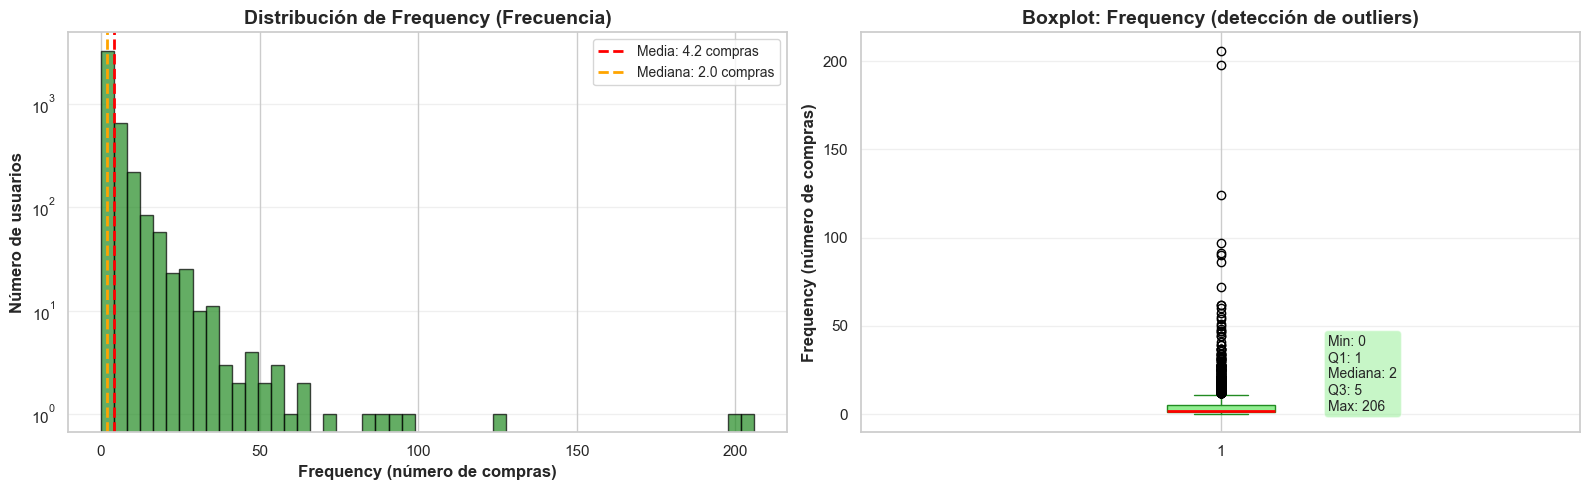

In [22]:
# ── Visualización de la distribución de Frequency ────────────────────────────

print('\nVISUALIZACIÓN: Distribución de Frequency')
print('='*80)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Gráfico 1: Histograma (escala logarítmica en Y) ───────────────────────
axes[0].hist(df_rfm['Frequency'], bins=50, color='forestgreen', edgecolor='black', alpha=0.7)
axes[0].axvline(df_rfm['Frequency'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df_rfm["Frequency"].mean():.1f} compras')
axes[0].axvline(df_rfm['Frequency'].median(), color='orange', linestyle='--', linewidth=2, label=f'Mediana: {df_rfm["Frequency"].median():.1f} compras')
axes[0].set_xlabel('Frequency (número de compras)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Número de usuarios', fontsize=12, fontweight='bold')
axes[0].set_title('Distribución de Frequency (Frecuencia)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)
# Escala logarítmica en Y si hay mucha concentración en valores bajos
axes[0].set_yscale('log')

# ── Gráfico 2: Boxplot ────────────────────────────────────────────────────────
axes[1].boxplot(df_rfm['Frequency'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightgreen', color='forestgreen'),
                whiskerprops=dict(color='forestgreen'),
                capprops=dict(color='forestgreen'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Frequency (número de compras)', fontsize=12, fontweight='bold')
axes[1].set_title('Boxplot: Frequency (detección de outliers)', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Añadir estadísticas al boxplot
stats_text = f'Min: {df_rfm["Frequency"].min():.0f}\nQ1: {df_rfm["Frequency"].quantile(0.25):.0f}\nMediana: {df_rfm["Frequency"].median():.0f}\nQ3: {df_rfm["Frequency"].quantile(0.75):.0f}\nMax: {df_rfm["Frequency"].max():.0f}'
axes[1].text(1.15, df_rfm['Frequency'].median(), stats_text, fontsize=10, 
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.tight_layout()

# Guardar gráfico
ruta_grafico = os.path.join(RUTA_GRAFICOS, '4.1.B_distribucion_frequency.png')
plt.savefig(ruta_grafico, dpi=300, bbox_inches='tight')
print(f'\n[OK] Gráfico guardado en: {ruta_grafico}')

plt.show()

print('\n' + '='*80)

---

### 4.1.C — MONETARY (Valor Monetario)

**Definición**: Valor total gastado por el usuario en compras (excluyendo devoluciones)

**Interpretación**:
- Monetary **bajo** (ej. £10-50) → Cliente de bajo valor económico
- Monetary **alto** (ej. £5,000+) → Cliente de alto valor / VIP

**Cálculo**:
```
Monetary = sum(TotalPrice) por usuario, solo donde TotalPrice > 0
```

**Exclusión aplicada**: Se excluyen líneas con `Quantity < 0` (cancelaciones/devoluciones) para contabilizar únicamente el gasto real en compras.

**Nota**: `TotalPrice = Quantity × UnitPrice` ya fue calculado en el proceso de limpieza.

In [23]:
# ══════════════════════════════════════════════════════════════════════════════
#   PASO 4.1.C: CÁLCULO DE MONETARY (VALOR MONETARIO)
# ══════════════════════════════════════════════════════════════════════════════

print('='*80)
print('  PASO 4.1.C: MONETARY (Valor Monetario)')
print('='*80)
print()

# ── 1. Filtrar solo líneas de compra (Quantity > 0) ──────────────────────────
print(f'Filtrando líneas de compra (excluir Quantity < 0)...')
print(f'  {'─'*78}')

total_lineas = len(df_transacciones)
print(f'     Total líneas (todas)              : {total_lineas:>10,}')

# Filtrar: solo líneas donde TotalPrice > 0 (compras reales, no devoluciones)
df_compras_monetario = df_transacciones[df_transacciones['TotalPrice'] > 0]
lineas_compra = len(df_compras_monetario)
print(f'     Líneas de COMPRA (TotalPrice > 0) : {lineas_compra:>10,}')

lineas_excluidas = total_lineas - lineas_compra
pct_excluidas = (lineas_excluidas / total_lineas * 100)
print(f'     Líneas EXCLUIDAS (devoluciones)   : {lineas_excluidas:>10,} ({pct_excluidas:.2f}%)')
print()

# ── 2. Calcular gasto total por usuario ──────────────────────────────────────
print(f'Calculando gasto total por usuario...')

monetary_por_usuario = df_compras_monetario.groupby('CustomerID')['TotalPrice'].sum()

print(f'   [OK] Monetary calculado para {len(monetary_por_usuario):,} usuarios')
print()

# ── 3. Agregar Monetary al DataFrame RFM ─────────────────────────────────────
print(f'Agregando Monetary al DataFrame RFM...')

df_rfm = df_rfm.merge(
    monetary_por_usuario.rename('Monetary'),
    left_on='CustomerID',
    right_index=True,
    how='left'
)

# Rellenar con 0 si hay usuarios sin compras positivas
df_rfm['Monetary'] = df_rfm['Monetary'].fillna(0).round(2)

print(f'   [OK] Monetary agregado correctamente')
print()

print(f'[OK] DataFrame RFM actualizado')
print(f'  {'─'*78}')
print(f'     Dimensiones : {df_rfm.shape[0]:,} usuarios × {df_rfm.shape[1]} columnas')
print(f'     Columnas    : {list(df_rfm.columns)}')
print()

# ── 4. Estadísticas descriptivas de Monetary ─────────────────────────────────
print(f'ESTADÍSTICAS DE MONETARY:')
print(f'  {'─'*78}')
print(f'     Mínimo         : £{df_rfm["Monetary"].min():>12,.2f}  (gasto mínimo registrado)')
print(f'     Máximo         : £{df_rfm["Monetary"].max():>12,.2f}  (cliente de mayor gasto)')
print(f'     Media          : £{df_rfm["Monetary"].mean():>12,.2f}')
print(f'     Mediana        : £{df_rfm["Monetary"].median():>12,.2f}')
print(f'     Desv. estándar : £{df_rfm["Monetary"].std():>12,.2f}')
print()

print(f'  Percentiles:')
print(f'     P25 (Q1)       : £{df_rfm["Monetary"].quantile(0.25):>12,.2f}')
print(f'     P50 (Mediana)  : £{df_rfm["Monetary"].quantile(0.50):>12,.2f}')
print(f'     P75 (Q3)       : £{df_rfm["Monetary"].quantile(0.75):>12,.2f}')
print(f'     P90            : £{df_rfm["Monetary"].quantile(0.90):>12,.2f}')
print(f'     P95            : £{df_rfm["Monetary"].quantile(0.95):>12,.2f}')
print(f'     P99            : £{df_rfm["Monetary"].quantile(0.99):>12,.2f}')
print()

# ── 5. Distribución de usuarios por rango de Monetary ────────────────────────
print(f'DISTRIBUCIÓN DE USUARIOS POR RANGO DE MONETARY:')
print(f'  {'─'*78}')

bins_m   = [0, 100, 500, 1000, 2500, 5000, 10000, float('inf')]
labels_m = ['£0-100', '£100-500', '£500-1K', '£1K-2.5K', '£2.5K-5K', '£5K-10K', '£10K+']
df_rfm['Monetary_Range'] = pd.cut(df_rfm['Monetary'], bins=bins_m, labels=labels_m, right=True)

dist_m = df_rfm['Monetary_Range'].value_counts().sort_index()
for rango, count in dist_m.items():
    pct = (count / len(df_rfm) * 100)
    print(f'     {str(rango):<15} : {count:>6,} usuarios ({pct:>6.2f}%)')

df_rfm.drop('Monetary_Range', axis=1, inplace=True)

print()
print('='*80)

  PASO 4.1.C: MONETARY (Valor Monetario)

Filtrando líneas de compra (excluir Quantity < 0)...
  ──────────────────────────────────────────────────────────────────────────────
     Total líneas (todas)              :    399,651
     Líneas de COMPRA (TotalPrice > 0) :    391,145
     Líneas EXCLUIDAS (devoluciones)   :      8,506 (2.13%)

Calculando gasto total por usuario...
   [OK] Monetary calculado para 4,334 usuarios

Agregando Monetary al DataFrame RFM...
   [OK] Monetary agregado correctamente

[OK] DataFrame RFM actualizado
  ──────────────────────────────────────────────────────────────────────────────
     Dimensiones : 4,362 usuarios × 4 columnas
     Columnas    : ['CustomerID', 'Recency', 'Frequency', 'Monetary']

ESTADÍSTICAS DE MONETARY:
  ──────────────────────────────────────────────────────────────────────────────
     Mínimo         : £        0.00  (gasto mínimo registrado)
     Máximo         : £  223,521.60  (cliente de mayor gasto)
     Media          : £    1,73


VISUALIZACIÓN: Distribución de Monetary

[OK] Gráfico guardado en: ../../../graphics/gr_clustering/preprocesing/4.1.C_distribucion_monetary.png


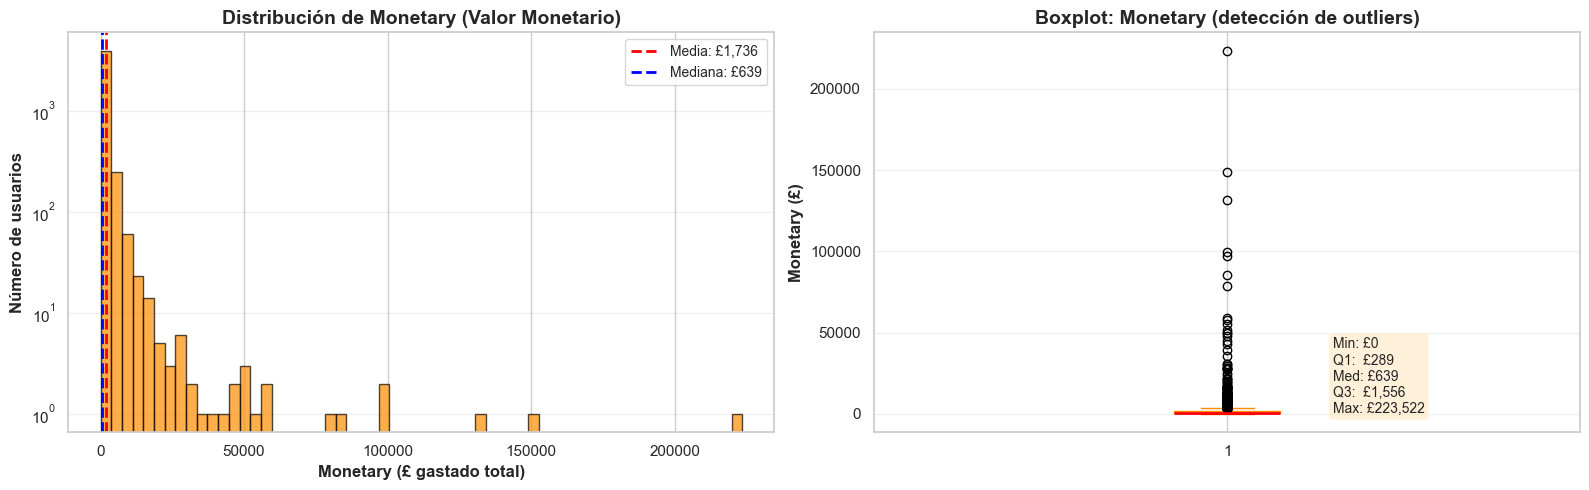

In [24]:
# ── Visualización de la distribución de Monetary ─────────────────────────────

print('\nVISUALIZACIÓN: Distribución de Monetary')
print('='*80)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Gráfico 1: Histograma (escala logarítmica en Y) ──────────────────────────
axes[0].hist(df_rfm['Monetary'], bins=60, color='darkorange', edgecolor='black', alpha=0.7)
axes[0].axvline(df_rfm['Monetary'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Media: £{df_rfm["Monetary"].mean():,.0f}')
axes[0].axvline(df_rfm['Monetary'].median(), color='blue', linestyle='--', linewidth=2,
                label=f'Mediana: £{df_rfm["Monetary"].median():,.0f}')
axes[0].set_xlabel('Monetary (£ gastado total)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Número de usuarios', fontsize=12, fontweight='bold')
axes[0].set_title('Distribución de Monetary (Valor Monetario)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_yscale('log')

# ── Gráfico 2: Boxplot ────────────────────────────────────────────────────────
axes[1].boxplot(df_rfm['Monetary'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='moccasin', color='darkorange'),
                whiskerprops=dict(color='darkorange'),
                capprops=dict(color='darkorange'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Monetary (£)', fontsize=12, fontweight='bold')
axes[1].set_title('Boxplot: Monetary (detección de outliers)', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

stats_text = (f'Min: £{df_rfm["Monetary"].min():,.0f}\n'
              f'Q1:  £{df_rfm["Monetary"].quantile(0.25):,.0f}\n'
              f'Med: £{df_rfm["Monetary"].median():,.0f}\n'
              f'Q3:  £{df_rfm["Monetary"].quantile(0.75):,.0f}\n'
              f'Max: £{df_rfm["Monetary"].max():,.0f}')
axes[1].text(1.15, df_rfm['Monetary'].median(), stats_text, fontsize=10,
             bbox=dict(boxstyle='round', facecolor='moccasin', alpha=0.5))

plt.tight_layout()

ruta_grafico = os.path.join(RUTA_GRAFICOS, '4.1.C_distribucion_monetary.png')
plt.savefig(ruta_grafico, dpi=300, bbox_inches='tight')
print(f'\n[OK] Gráfico guardado en: {ruta_grafico}')

plt.show()

print('\n' + '='*80)

In [25]:
# ── Vista previa del DataFrame RFM completo (R + F + M) ──────────────────────

print('\nVISTA PREVIA DEL DATAFRAME RFM COMPLETO (Recency + Frequency + Monetary):')
print('='*80)
print()

print('TOP 10: Clientes de MAYOR VALOR (Monetary más alto):')
display(df_rfm.nlargest(10, 'Monetary'))

print()
print('TOP 10: Clientes de MENOR VALOR (Monetary más bajo):')
display(df_rfm.nsmallest(10, 'Monetary'))

print()
print('Muestra aleatoria de 10 usuarios:')
display(df_rfm.sample(10, random_state=42).sort_values('Monetary', ascending=False))

print()
print('RESUMEN ESTADÍSTICO COMPLETO DEL DATAFRAME RFM:')
print('─'*80)
display(df_rfm[['Recency', 'Frequency', 'Monetary']].describe())


VISTA PREVIA DEL DATAFRAME RFM COMPLETO (Recency + Frequency + Monetary):

TOP 10: Clientes de MAYOR VALOR (Monetary más alto):


,CustomerID,Recency,Frequency,Monetary
1699,14646.00,2,72,223521.60
4223,18102.00,1,60,149098.00
1891,14911.00,1,198,131859.82
55,12415.00,24,20,99547.57
1341,14156.00,10,54,97407.69
3792,17511.00,3,31,85314.24
3749,17450.00,8,46,78794.68
2188,15311.00,1,91,59213.71
566,13089.00,3,97,57512.36
1001,13694.00,4,50,55190.26



TOP 10: Clientes de MENOR VALOR (Monetary más bajo):


,CustomerID,Recency,Frequency,Monetary
210,12605.00,365,0,0.00
262,12666.00,359,0,0.00
413,12870.00,366,0,0.00
465,12943.00,301,0,0.00
1000,13693.00,325,0,0.00
1102,13829.00,359,0,0.00
1196,13958.00,372,0,0.00
1314,14119.00,354,0,0.00
1380,14213.00,372,0,0.00
1684,14627.00,312,0,0.00



Muestra aleatoria de 10 usuarios:


,CustomerID,Recency,Frequency,Monetary
179,12572.00,9,2,904.02
3167,16644.00,178,2,833.78
2688,15994.00,55,1,410.07
2740,16063.00,260,1,335.32
2191,15314.00,199,1,327.97
2529,15766.00,64,1,315.06
1786,14764.00,44,1,278.30
2480,15703.00,265,1,211.50
1578,14485.00,39,1,162.80
3424,16988.00,5,1,126.12



RESUMEN ESTADÍSTICO COMPLETO DEL DATAFRAME RFM:
────────────────────────────────────────────────────────────────────────────────


,Recency,Frequency,Monetary
count,4362.00,4362.00,4362.00
mean,92.17,4.22,1736.02
std,100.97,7.62,6264.09
min,1.00,0.00,0.00
25%,17.00,1.00,288.99
50%,50.00,2.00,639.27
75%,143.00,5.00,1556.21
max,374.00,206.00,223521.60


---

## PASO 4.2: Variables de Comportamiento de Compra

Las variables RFM capturan el **qué** (cuánto, cuándo, cuántas veces), pero no el **cómo** compra el usuario. Las variables de comportamiento añaden profundidad al perfil:

### Por qué añadir variables de comportamiento

| Limitación del RFM puro | Variable que lo resuelve |
|-------------------------|--------------------------|
| Frequency ignora el tiempo: 10 compras en 1 mes ≠ 10 compras en 1 año | `frecuencia_mensual` |
| No distingue comprador regular de comprador esporádico | `dias_entre_compras` |
| No sabe si el usuario compra en varios meses o concentra todo en uno | `num_meses_activo` |

---

### 4.2.A — Frecuencia Temporal

**Variables a calcular**:

| Variable | Definición | Fórmula |
|----------|------------|---------|
| `num_meses_activo` | Meses distintos en que el usuario realizó al menos una compra | `count(distinct Mes por usuario)` |
| `frecuencia_mensual` | Compras promedio por mes activo | `Frequency / num_meses_activo` |
| `dias_entre_compras` | Días promedio entre compras consecutivas | `periodo_activo / Frequency` |

**Notas de cálculo**:
- `periodo_activo` = días entre primera y última compra del usuario (no el dataset completo)
- Para usuarios con `Frequency = 1`, `dias_entre_compras = 0` (solo hay una compra, no hay intervalo)
- Solo se usan transacciones de **compra** (excluidas cancelaciones)

In [26]:
# ══════════════════════════════════════════════════════════════════════════════
#   PASO 4.2.A: FRECUENCIA TEMPORAL
#   Variables: num_meses_activo, frecuencia_mensual, dias_entre_compras
# ══════════════════════════════════════════════════════════════════════════════

print('='*80)
print('  PASO 4.2.A: FRECUENCIA TEMPORAL')
print('='*80)
print()

# Reutilizamos df_compras (ya filtrado: solo facturas sin 'C')
# Si no está en memoria, recalcular
df_compras = df_transacciones[~df_transacciones['InvoiceNo'].astype(str).str.startswith('C')]

# ── 1. num_meses_activo: Meses distintos en que compró ───────────────────────
print(f'Calculando num_meses_activo...')
print(f'  {'─'*78}')

# Extraer año-mes de la fecha para distinguir meses
df_compras = df_compras.copy()
df_compras['anio_mes'] = df_compras['InvoiceDate'].dt.to_period('M')

num_meses_activo = df_compras.groupby('CustomerID')['anio_mes'].nunique()

print(f'     [OK] Calculado para {len(num_meses_activo):,} usuarios')
print(f'     Rango: entre {num_meses_activo.min()} y {num_meses_activo.max()} meses activos')
print()

# ── 2. Calcular el periodo activo por usuario (primera a última compra) ──────
print(f'Calculando periodo activo por usuario (primera a última compra)...')

fecha_primera_compra = df_compras.groupby('CustomerID')['InvoiceDate'].min()
fecha_ultima_compra  = df_compras.groupby('CustomerID')['InvoiceDate'].max()
periodo_activo_dias  = (fecha_ultima_compra - fecha_primera_compra).dt.days

print(f'     [OK] Periodo activo calculado para {len(periodo_activo_dias):,} usuarios')
print()

# ── 3. frecuencia_mensual: Frequency / num_meses_activo ──────────────────────
print(f'Calculando frecuencia_mensual (compras por mes activo)...')

# Construir DataFrame auxiliar
df_temp = pd.DataFrame({
    'CustomerID'      : num_meses_activo.index,
    'num_meses_activo': num_meses_activo.values,
    'periodo_activo'  : periodo_activo_dias.values
})

# Merge con df_rfm para tener Frequency disponible
df_temp = df_temp.merge(df_rfm[['CustomerID', 'Frequency']], on='CustomerID', how='left')

# frecuencia_mensual = Frequency / num_meses_activo
df_temp['frecuencia_mensual'] = (df_temp['Frequency'] / df_temp['num_meses_activo']).round(2)

print(f'     [OK] frecuencia_mensual calculada')
print()

# ── 4. dias_entre_compras: periodo_activo / Frequency ────────────────────────
print(f'Calculando dias_entre_compras (días promedio entre compras)...')

# Para usuarios con Frequency = 1, el intervalo entre compras es 0 (solo 1 compra)
df_temp['dias_entre_compras'] = np.where(
    df_temp['Frequency'] <= 1,
    0,
    (df_temp['periodo_activo'] / (df_temp['Frequency'] - 1)).round(1)
)

print(f'     [OK] dias_entre_compras calculado')
print()

# ── 5. Merge al DataFrame principal df_rfm ───────────────────────────────────
print(f'Agregando variables al DataFrame RFM...')

df_rfm = df_rfm.merge(
    df_temp[['CustomerID', 'num_meses_activo', 'frecuencia_mensual', 'dias_entre_compras']],
    on='CustomerID',
    how='left'
)

# Rellenar posibles nulos
df_rfm['num_meses_activo']  = df_rfm['num_meses_activo'].fillna(0).astype(int)
df_rfm['frecuencia_mensual']= df_rfm['frecuencia_mensual'].fillna(0).round(2)
df_rfm['dias_entre_compras']= df_rfm['dias_entre_compras'].fillna(0).round(1)

print(f'   [OK] Variables agregadas correctamente')
print()

print(f'[OK] DataFrame RFM actualizado')
print(f'  {'─'*78}')
print(f'     Dimensiones : {df_rfm.shape[0]:,} usuarios × {df_rfm.shape[1]} columnas')
print(f'     Columnas    : {list(df_rfm.columns)}')
print()

# ── 6. Estadísticas de las tres variables ────────────────────────────────────
print(f'ESTADÍSTICAS DE VARIABLES DE FRECUENCIA TEMPORAL:')
print(f'  {'─'*78}')

for col, unidad in [('num_meses_activo', 'meses'), ('frecuencia_mensual', 'compras/mes'), ('dias_entre_compras', 'días')]:
    print(f'\n  {col}:')
    print(f'     Mínimo    : {df_rfm[col].min():>8.1f} {unidad}')
    print(f'     Máximo    : {df_rfm[col].max():>8.1f} {unidad}')
    print(f'     Media     : {df_rfm[col].mean():>8.2f} {unidad}')
    print(f'     Mediana   : {df_rfm[col].median():>8.2f} {unidad}')

print()
print('='*80)

  PASO 4.2.A: FRECUENCIA TEMPORAL

Calculando num_meses_activo...
  ──────────────────────────────────────────────────────────────────────────────
     [OK] Calculado para 4,334 usuarios
     Rango: entre 1 y 13 meses activos

Calculando periodo activo por usuario (primera a última compra)...
     [OK] Periodo activo calculado para 4,334 usuarios

Calculando frecuencia_mensual (compras por mes activo)...
     [OK] frecuencia_mensual calculada

Calculando dias_entre_compras (días promedio entre compras)...
     [OK] dias_entre_compras calculado

Agregando variables al DataFrame RFM...
   [OK] Variables agregadas correctamente

[OK] DataFrame RFM actualizado
  ──────────────────────────────────────────────────────────────────────────────
     Dimensiones : 4,362 usuarios × 7 columnas
     Columnas    : ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'num_meses_activo', 'frecuencia_mensual', 'dias_entre_compras']

ESTADÍSTICAS DE VARIABLES DE FRECUENCIA TEMPORAL:
  ────────────────────


VISUALIZACIÓN: Variables de Frecuencia Temporal

[OK] Gráfico guardado en: ../../../graphics/gr_clustering/preprocesing/4.2.A_frecuencia_temporal.png


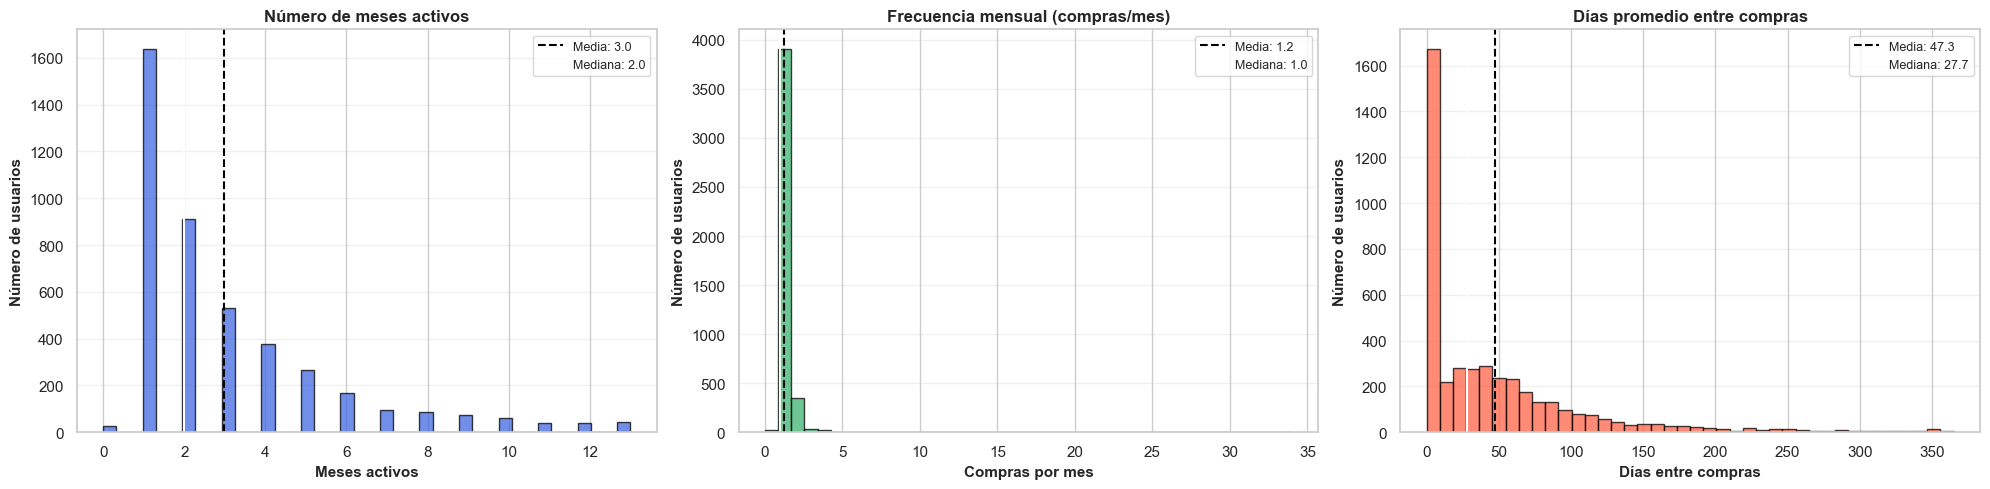

In [27]:
# ── Visualización de las variables de frecuencia temporal ────────────────────

print('\nVISUALIZACIÓN: Variables de Frecuencia Temporal')
print('='*80)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

variables = [
    ('num_meses_activo',   'Meses activos',            'Número de meses activos',         'royalblue'),
    ('frecuencia_mensual', 'Compras por mes',           'Frecuencia mensual (compras/mes)', 'mediumseagreen'),
    ('dias_entre_compras', 'Días entre compras',        'Días promedio entre compras',      'tomato'),
]

for ax, (col, xlabel, title, color) in zip(axes, variables):
    ax.hist(df_rfm[col], bins=40, color=color, edgecolor='black', alpha=0.75)
    ax.axvline(df_rfm[col].mean(),   color='black',  linestyle='--', linewidth=1.5,
               label=f'Media: {df_rfm[col].mean():.1f}')
    ax.axvline(df_rfm[col].median(), color='white', linestyle='-',  linewidth=1.5,
               label=f'Mediana: {df_rfm[col].median():.1f}')
    ax.set_xlabel(xlabel, fontsize=11, fontweight='bold')
    ax.set_ylabel('Número de usuarios', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

ruta_grafico = os.path.join(RUTA_GRAFICOS, '4.2.A_frecuencia_temporal.png')
plt.savefig(ruta_grafico, dpi=300, bbox_inches='tight')
print(f'\n[OK] Gráfico guardado en: {ruta_grafico}')

plt.show()
print('\n' + '='*80)


### 4.2.B — Valor de Compra

Las variables de frecuencia temporal nos dicen **cuándo** y **con qué regularidad** compra el usuario, pero no **cuánto gasta en cada visita** ni **cómo distribuye su gasto a lo largo del tiempo**. Estas dos variables complementan el Monetary del RFM añadiendo granularidad:

| Limitación del RFM puro | Variable que lo resuelve |
|-------------------------|--------------------------|
| Monetary alto puede deberse a muchas compras pequeñas o a pocas compras grandes | `ticket_promedio` |
| No sabemos si el gasto está concentrado en un mes o repartido a lo largo del año | `gasto_mensual` |

| Variable | Definición | Fórmula |
|----------|------------|---------|
| `ticket_promedio` | Gasto medio por transacción (£ por compra) | `Monetary / Frequency` |
| `gasto_mensual` | Gasto medio por mes activo (£ por mes) | `Monetary / num_meses_activo` |

**Notas de cálculo**:
- Para usuarios con `Frequency = 0`, `ticket_promedio = 0`
- Para usuarios con `num_meses_activo = 0`, `gasto_mensual = 0`
- Ambas variables heredan el mismo filtro de Monetary (solo `TotalPrice > 0`)

In [28]:
# ══════════════════════════════════════════════════════════════════════════════
#   PASO 4.2.B: VALOR DE COMPRA
#   Variables: ticket_promedio, gasto_mensual
# ══════════════════════════════════════════════════════════════════════════════

print('='*80)
print('  PASO 4.2.B: VALOR DE COMPRA')
print('='*80)
print()

# ── 1. ticket_promedio: Monetary / Frequency ─────────────────────────────────
print('Calculando ticket_promedio (Monetary / Frequency)...')
print(f'  {"─"*78}')

df_rfm['ticket_promedio'] = np.where(
    df_rfm['Frequency'] == 0,
    0,
    (df_rfm['Monetary'] / df_rfm['Frequency']).round(2)
)

print(f'     [OK] ticket_promedio calculado para {len(df_rfm):,} usuarios')
print()

# ── 2. gasto_mensual: Monetary / num_meses_activo ────────────────────────────
print('Calculando gasto_mensual (Monetary / num_meses_activo)...')
print(f'  {"─"*78}')

df_rfm['gasto_mensual'] = np.where(
    df_rfm['num_meses_activo'] == 0,
    0,
    (df_rfm['Monetary'] / df_rfm['num_meses_activo']).round(2)
)

print(f'     [OK] gasto_mensual calculado para {len(df_rfm):,} usuarios')
print()

# ── 3. Estado actual del DataFrame ───────────────────────────────────────────
print(f'[OK] DataFrame RFM actualizado')
print(f'  {"─"*78}')
print(f'     Dimensiones : {df_rfm.shape[0]:,} usuarios × {df_rfm.shape[1]} columnas')
print(f'     Columnas    : {list(df_rfm.columns)}')
print()

# ── 4. Estadísticas de las dos variables ─────────────────────────────────────
print('ESTADÍSTICAS DE VARIABLES DE VALOR DE COMPRA:')
print(f'  {"─"*78}')

for col, unidad in [('ticket_promedio', '£/compra'), ('gasto_mensual', '£/mes')]:
    print(f'\n  {col}:')
    print(f'     Mínimo    : £{df_rfm[col].min():>10,.2f}  ({unidad})')
    print(f'     Máximo    : £{df_rfm[col].max():>10,.2f}  ({unidad})')
    print(f'     Media     : £{df_rfm[col].mean():>10,.2f}  ({unidad})')
    print(f'     Mediana   : £{df_rfm[col].median():>10,.2f}  ({unidad})')
    print(f'     P75 (Q3)  : £{df_rfm[col].quantile(0.75):>10,.2f}  ({unidad})')
    print(f'     P95       : £{df_rfm[col].quantile(0.95):>10,.2f}  ({unidad})')

print()
print('='*80)

  PASO 4.2.B: VALOR DE COMPRA

Calculando ticket_promedio (Monetary / Frequency)...
  ──────────────────────────────────────────────────────────────────────────────
     [OK] ticket_promedio calculado para 4,362 usuarios

Calculando gasto_mensual (Monetary / num_meses_activo)...
  ──────────────────────────────────────────────────────────────────────────────
     [OK] gasto_mensual calculado para 4,362 usuarios

[OK] DataFrame RFM actualizado
  ──────────────────────────────────────────────────────────────────────────────
     Dimensiones : 4,362 usuarios × 9 columnas
     Columnas    : ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'num_meses_activo', 'frecuencia_mensual', 'dias_entre_compras', 'ticket_promedio', 'gasto_mensual']

ESTADÍSTICAS DE VARIABLES DE VALOR DE COMPRA:
  ──────────────────────────────────────────────────────────────────────────────

  ticket_promedio:
     Mínimo    : £      0.00  (£/compra)
     Máximo    : £  9,029.26  (£/compra)
     Media     : £    349


VISUALIZACIÓN: Variables de Valor de Compra

[OK] Gráfico guardado en: ../../../graphics/gr_clustering/preprocesing/4.2.B_valor_compra.png


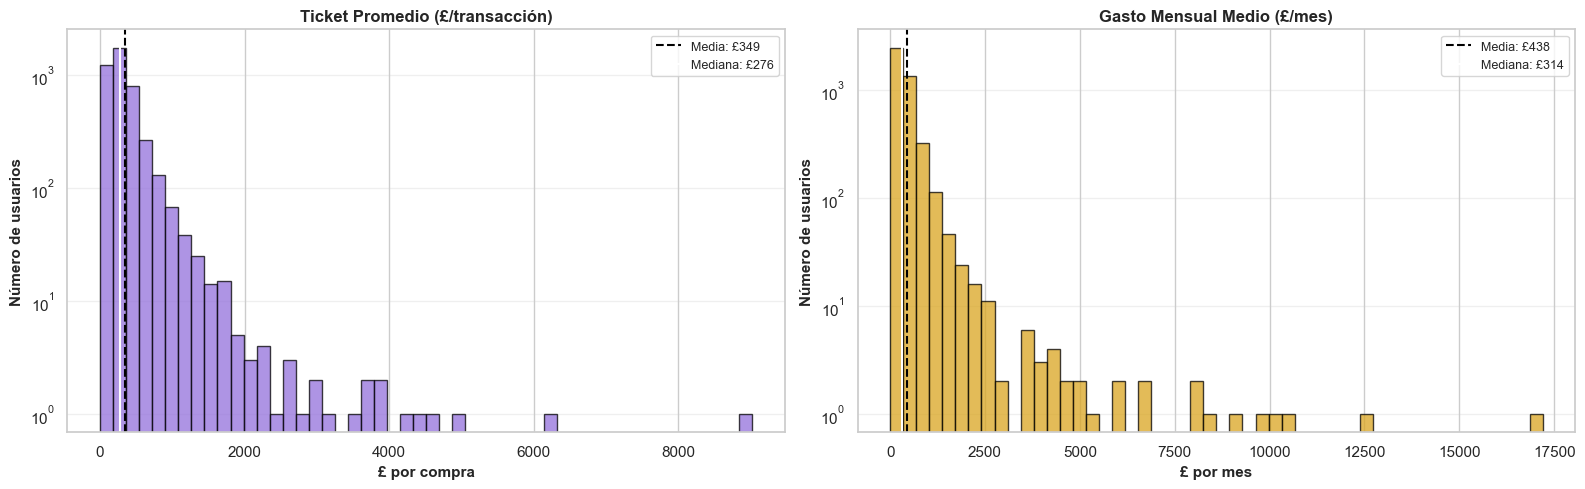

In [29]:
# ── Visualización de las variables de valor de compra ────────────────────────

print('\nVISUALIZACIÓN: Variables de Valor de Compra')
print('='*80)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

variables = [
    ('ticket_promedio', '£ por compra',  'Ticket Promedio (£/transacción)', 'mediumpurple'),
    ('gasto_mensual',   '£ por mes',     'Gasto Mensual Medio (£/mes)',     'goldenrod'),
]

for ax, (col, xlabel, title, color) in zip(axes, variables):
    ax.hist(df_rfm[col], bins=50, color=color, edgecolor='black', alpha=0.75)
    ax.axvline(df_rfm[col].mean(),   color='black', linestyle='--', linewidth=1.5,
               label=f'Media: £{df_rfm[col].mean():,.0f}')
    ax.axvline(df_rfm[col].median(), color='white', linestyle='-',  linewidth=1.5,
               label=f'Mediana: £{df_rfm[col].median():,.0f}')
    ax.set_xlabel(xlabel, fontsize=11, fontweight='bold')
    ax.set_ylabel('Número de usuarios', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_yscale('log')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

ruta_grafico = os.path.join(RUTA_GRAFICOS, '4.2.B_valor_compra.png')
plt.savefig(ruta_grafico, dpi=300, bbox_inches='tight')
print(f'\n[OK] Gráfico guardado en: {ruta_grafico}')

plt.show()
print('\n' + '='*80)

---

### 4.2.C — Diversidad de Productos

Frequency nos dice cuántas veces compra el usuario, pero no qué variedad de productos elige. Dos usuarios con la misma Frequency pueden tener perfiles muy distintos: uno compra siempre el mismo artículo, otro explora continuamente el catálogo.

| Limitación del RFM + variables anteriores | Variable que lo resuelve |
|-------------------------------------------|--------------------------|
| No distingue compradores especializados de compradores exploradores | `num_productos_unicos` |
| Frequency no informa sobre la amplitud del pedido medio | `diversidad_producto` |

| Variable | Definición | Fórmula |
|----------|------------|---------|
| `num_productos_unicos` | Número de StockCode distintos comprados por el usuario | `count(distinct StockCode por usuario)` |
| `diversidad_producto` | Productos únicos promedio por transacción | `num_productos_unicos / Frequency` |

**Notas de cálculo**:
- Solo se usan transacciones de **compra** (sin cancelaciones)
- Para usuarios con `Frequency = 0`, `diversidad_producto = 0`

In [30]:
# ══════════════════════════════════════════════════════════════════════════════
#   PASO 4.2.C: DIVERSIDAD DE PRODUCTOS
#   Variables: num_productos_unicos, diversidad_producto
# ══════════════════════════════════════════════════════════════════════════════

print('='*80)
print('  PASO 4.2.C: DIVERSIDAD DE PRODUCTOS')
print('='*80)
print()

# df_compras ya está en memoria (transacciones sin cancelaciones)

# ── 1. num_productos_unicos: StockCode distintos por usuario ─────────────────
print('Calculando num_productos_unicos...')
print(f'  {"─"*78}')

num_productos_unicos = df_compras.groupby('CustomerID')['StockCode'].nunique()

print(f'     [OK] Calculado para {len(num_productos_unicos):,} usuarios')
print(f'     Rango: entre {num_productos_unicos.min()} y {num_productos_unicos.max()} productos únicos')
print()

# ── 2. Merge y calcular diversidad_producto ──────────────────────────────────
print('Calculando diversidad_producto (num_productos_unicos / Frequency)...')
print(f'  {"─"*78}')

df_rfm = df_rfm.merge(
    num_productos_unicos.rename('num_productos_unicos'),
    left_on='CustomerID',
    right_index=True,
    how='left'
)
df_rfm['num_productos_unicos'] = df_rfm['num_productos_unicos'].fillna(0).astype(int)

df_rfm['diversidad_producto'] = np.where(
    df_rfm['Frequency'] == 0,
    0,
    (df_rfm['num_productos_unicos'] / df_rfm['Frequency']).round(2)
)

print(f'     [OK] diversidad_producto calculada')
print()

# ── 3. Estado actual del DataFrame ───────────────────────────────────────────
print(f'[OK] DataFrame RFM actualizado')
print(f'  {"─"*78}')
print(f'     Dimensiones : {df_rfm.shape[0]:,} usuarios × {df_rfm.shape[1]} columnas')
print(f'     Columnas    : {list(df_rfm.columns)}')
print()

# ── 4. Estadísticas ──────────────────────────────────────────────────────────
print('ESTADÍSTICAS DE VARIABLES DE DIVERSIDAD:')
print(f'  {"─"*78}')

for col, unidad in [('num_productos_unicos', 'productos'), ('diversidad_producto', 'productos/compra')]:
    print(f'\n  {col}:')
    print(f'     Mínimo    : {df_rfm[col].min():>8.1f}  ({unidad})')
    print(f'     Máximo    : {df_rfm[col].max():>8.1f}  ({unidad})')
    print(f'     Media     : {df_rfm[col].mean():>8.2f}  ({unidad})')
    print(f'     Mediana   : {df_rfm[col].median():>8.2f}  ({unidad})')
    print(f'     P75 (Q3)  : {df_rfm[col].quantile(0.75):>8.2f}  ({unidad})')
    print(f'     P95       : {df_rfm[col].quantile(0.95):>8.2f}  ({unidad})')

print()
print('='*80)

  PASO 4.2.C: DIVERSIDAD DE PRODUCTOS

Calculando num_productos_unicos...
  ──────────────────────────────────────────────────────────────────────────────
     [OK] Calculado para 4,334 usuarios
     Rango: entre 1 y 1785 productos únicos

Calculando diversidad_producto (num_productos_unicos / Frequency)...
  ──────────────────────────────────────────────────────────────────────────────
     [OK] diversidad_producto calculada

[OK] DataFrame RFM actualizado
  ──────────────────────────────────────────────────────────────────────────────
     Dimensiones : 4,362 usuarios × 11 columnas
     Columnas    : ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'num_meses_activo', 'frecuencia_mensual', 'dias_entre_compras', 'ticket_promedio', 'gasto_mensual', 'num_productos_unicos', 'diversidad_producto']

ESTADÍSTICAS DE VARIABLES DE DIVERSIDAD:
  ──────────────────────────────────────────────────────────────────────────────

  num_productos_unicos:
     Mínimo    :      0.0  (productos)
     


VISUALIZACIÓN: Variables de Diversidad de Productos

[OK] Gráfico guardado en: ../../../graphics/gr_clustering/preprocesing/4.2.C_diversidad_producto.png


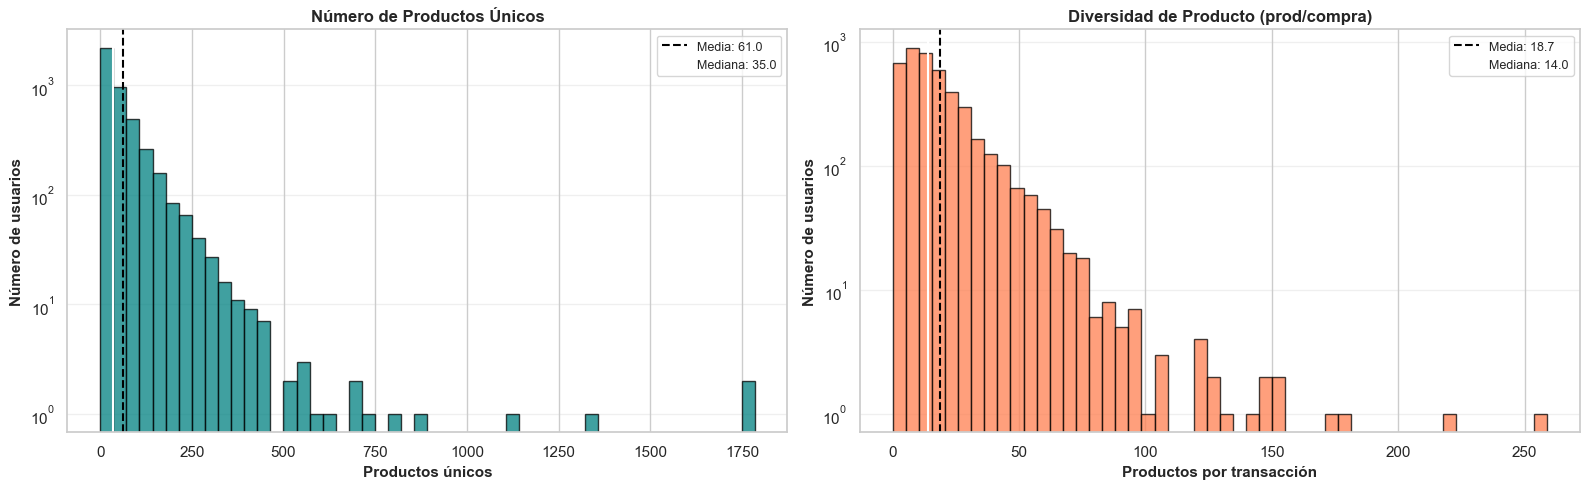

In [31]:
# ── Visualización de las variables de diversidad de productos ────────────────

print('\nVISUALIZACIÓN: Variables de Diversidad de Productos')
print('='*80)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

variables = [
    ('num_productos_unicos', 'Productos únicos',         'Número de Productos Únicos',          'teal'),
    ('diversidad_producto',  'Productos por transacción','Diversidad de Producto (prod/compra)', 'coral'),
]

for ax, (col, xlabel, title, color) in zip(axes, variables):
    ax.hist(df_rfm[col], bins=50, color=color, edgecolor='black', alpha=0.75)
    ax.axvline(df_rfm[col].mean(),   color='black', linestyle='--', linewidth=1.5,
               label=f'Media: {df_rfm[col].mean():.1f}')
    ax.axvline(df_rfm[col].median(), color='white', linestyle='-',  linewidth=1.5,
               label=f'Mediana: {df_rfm[col].median():.1f}')
    ax.set_xlabel(xlabel, fontsize=11, fontweight='bold')
    ax.set_ylabel('Número de usuarios', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_yscale('log')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

ruta_grafico = os.path.join(RUTA_GRAFICOS, '4.2.C_diversidad_producto.png')
plt.savefig(ruta_grafico, dpi=300, bbox_inches='tight')
print(f'\n[OK] Gráfico guardado en: {ruta_grafico}')

plt.show()
print('\n' + '='*80)

---

### 4.2.D — Cantidad de Productos

Las variables anteriores trabajan con el valor monetario y la diversidad, pero no con el **volumen físico** de lo que compra el usuario. Un usuario puede gastar mucho comprando pocos artículos caros, o poco comprando muchos artículos baratos. Esta variable captura el comportamiento de volumen.

| Limitación del RFM + variables anteriores | Variable que lo resuelve |
|-------------------------------------------|--------------------------|
| Monetary y ticket_promedio son valores monetarios, no dicen cuántas unidades compra | `cantidad_total_comprada` |
| No sabemos si el usuario hace pedidos grandes o pequeños de media | `cantidad_promedio_por_compra` |

<br>

| Variable | Definición | Fórmula |
|----------|------------|---------|
| `cantidad_total_comprada` | Total de unidades compradas por el usuario | `sum(Quantity > 0 por usuario)` |
| `cantidad_promedio_por_compra` | Unidades medias por transacción | `cantidad_total_comprada / Frequency` |

**Notas de cálculo**:
- Solo se suman cantidades positivas (`Quantity > 0`), excluyendo devoluciones
- Para usuarios con `Frequency = 0`, `cantidad_promedio_por_compra = 0`

In [32]:
# ══════════════════════════════════════════════════════════════════════════════
#   PASO 4.2.D: CANTIDAD DE PRODUCTOS
#   Variables: cantidad_total_comprada, cantidad_promedio_por_compra
# ══════════════════════════════════════════════════════════════════════════════

print('='*80)
print('  PASO 4.2.D: CANTIDAD DE PRODUCTOS')
print('='*80)
print()

# ── 1. cantidad_total_comprada: sum(Quantity > 0) por usuario ─────────────────
print('Calculando cantidad_total_comprada...')
print(f'  {"─"*78}')

# Filtrar solo líneas con cantidad positiva (compras reales)
df_compras_cantidad = df_compras[df_compras['Quantity'] > 0]

cantidad_total = df_compras_cantidad.groupby('CustomerID')['Quantity'].sum()

print(f'     [OK] Calculado para {len(cantidad_total):,} usuarios')
print(f'     Rango: entre {cantidad_total.min():,} y {cantidad_total.max():,} unidades')
print()

# ── 2. Merge y calcular cantidad_promedio_por_compra ─────────────────────────
print('Calculando cantidad_promedio_por_compra (cantidad_total / Frequency)...')
print(f'  {"─"*78}')

df_rfm = df_rfm.merge(
    cantidad_total.rename('cantidad_total_comprada'),
    left_on='CustomerID',
    right_index=True,
    how='left'
)
df_rfm['cantidad_total_comprada'] = df_rfm['cantidad_total_comprada'].fillna(0).astype(int)

df_rfm['cantidad_promedio_por_compra'] = np.where(
    df_rfm['Frequency'] == 0,
    0,
    (df_rfm['cantidad_total_comprada'] / df_rfm['Frequency']).round(1)
)

print(f'     [OK] cantidad_promedio_por_compra calculada')
print()

# ── 3. Estado actual del DataFrame ───────────────────────────────────────────
print(f'[OK] DataFrame RFM actualizado')
print(f'  {"─"*78}')
print(f'     Dimensiones : {df_rfm.shape[0]:,} usuarios × {df_rfm.shape[1]} columnas')
print(f'     Columnas    : {list(df_rfm.columns)}')
print()

# ── 4. Estadísticas ──────────────────────────────────────────────────────────
print('ESTADÍSTICAS DE VARIABLES DE CANTIDAD:')
print(f'  {"─"*78}')

for col, unidad in [('cantidad_total_comprada', 'unidades'), ('cantidad_promedio_por_compra', 'unidades/compra')]:
    print(f'\n  {col}:')
    print(f'     Mínimo    : {df_rfm[col].min():>10.1f}  ({unidad})')
    print(f'     Máximo    : {df_rfm[col].max():>10.1f}  ({unidad})')
    print(f'     Media     : {df_rfm[col].mean():>10.2f}  ({unidad})')
    print(f'     Mediana   : {df_rfm[col].median():>10.2f}  ({unidad})')
    print(f'     P75 (Q3)  : {df_rfm[col].quantile(0.75):>10.2f}  ({unidad})')
    print(f'     P95       : {df_rfm[col].quantile(0.95):>10.2f}  ({unidad})')

print()
print('='*80)

  PASO 4.2.D: CANTIDAD DE PRODUCTOS

Calculando cantidad_total_comprada...
  ──────────────────────────────────────────────────────────────────────────────
     [OK] Calculado para 4,334 usuarios
     Rango: entre 1 y 147,618 unidades

Calculando cantidad_promedio_por_compra (cantidad_total / Frequency)...
  ──────────────────────────────────────────────────────────────────────────────
     [OK] cantidad_promedio_por_compra calculada

[OK] DataFrame RFM actualizado
  ──────────────────────────────────────────────────────────────────────────────
     Dimensiones : 4,362 usuarios × 13 columnas
     Columnas    : ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'num_meses_activo', 'frecuencia_mensual', 'dias_entre_compras', 'ticket_promedio', 'gasto_mensual', 'num_productos_unicos', 'diversidad_producto', 'cantidad_total_comprada', 'cantidad_promedio_por_compra']

ESTADÍSTICAS DE VARIABLES DE CANTIDAD:
  ──────────────────────────────────────────────────────────────────────────────

  c


VISUALIZACIÓN: Variables de Cantidad de Productos

[OK] Gráfico guardado en: ../../../graphics/gr_clustering/preprocesing/4.2.D_cantidad_productos.png


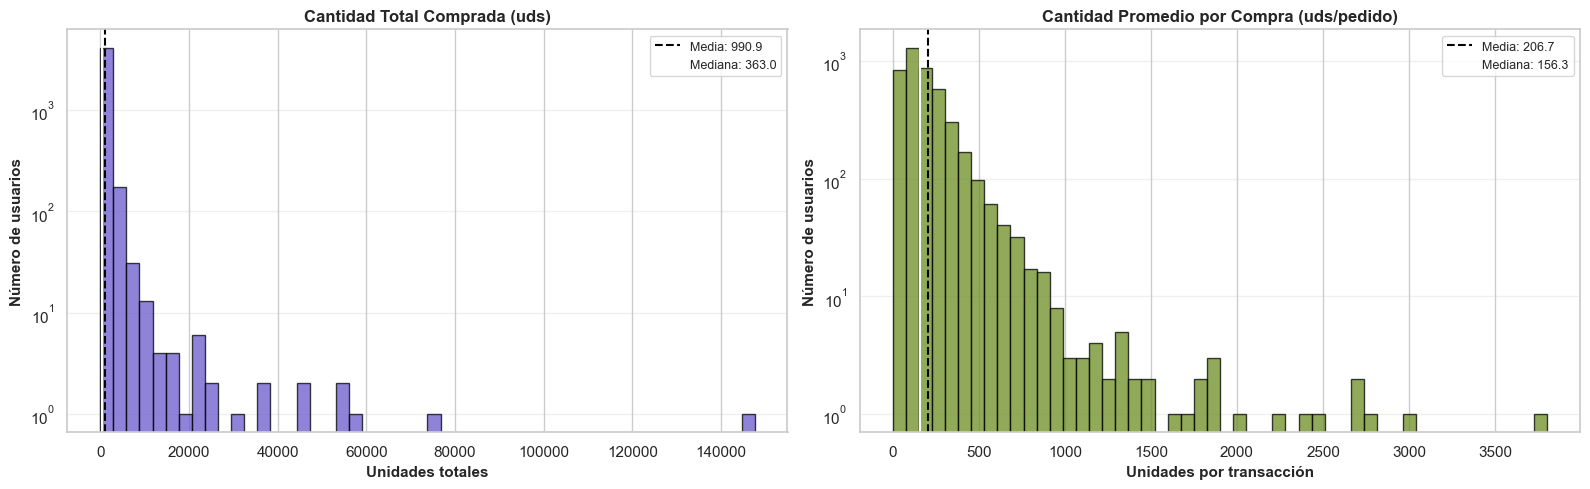

In [33]:
# ── Visualización de las variables de cantidad ───────────────────────────────

print('\nVISUALIZACIÓN: Variables de Cantidad de Productos')
print('='*80)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

variables = [
    ('cantidad_total_comprada',     'Unidades totales',      'Cantidad Total Comprada (uds)',          'slateblue'),
    ('cantidad_promedio_por_compra','Unidades por transacción','Cantidad Promedio por Compra (uds/pedido)', 'olivedrab'),
]

for ax, (col, xlabel, title, color) in zip(axes, variables):
    ax.hist(df_rfm[col], bins=50, color=color, edgecolor='black', alpha=0.75)
    ax.axvline(df_rfm[col].mean(),   color='black', linestyle='--', linewidth=1.5,
               label=f'Media: {df_rfm[col].mean():.1f}')
    ax.axvline(df_rfm[col].median(), color='white', linestyle='-',  linewidth=1.5,
               label=f'Mediana: {df_rfm[col].median():.1f}')
    ax.set_xlabel(xlabel, fontsize=11, fontweight='bold')
    ax.set_ylabel('Número de usuarios', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_yscale('log')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

ruta_grafico = os.path.join(RUTA_GRAFICOS, '4.2.D_cantidad_productos.png')
plt.savefig(ruta_grafico, dpi=300, bbox_inches='tight')
print(f'\n[OK] Gráfico guardado en: {ruta_grafico}')

plt.show()
print('\n' + '='*80)

---

## PASO 4.3: Variables de Comportamiento de Devolución

Las cancelaciones están **conservadas** en el dataset (columna `EsCancelacion` + InvoiceNo comenzando por 'C'). Esto nos permite calcular el comportamiento de devolución de cada usuario, que es un indicador clave de su perfil: un cliente que cancela frecuentemente puede indicar insatisfacción, compras por impulso o un patrón de abuso.

| Por qué incluir variables de devolución | Valor para el clustering |
|-----------------------------------------|--------------------------|
| Un usuario con Frequency=20 y 15 cancelaciones es muy distinto a uno con 20 compras y 0 cancelaciones | Distingue clientes fieles de clientes problemáticos |
| La tasa de cancelación mide la proporción de operaciones que acaban en devolución | Perfila el riesgo por segmento |

| Variable | Definición | Fórmula |
|----------|------------|---------|
| `num_cancelaciones` | Número de facturas canceladas por el usuario | `count(distinct InvoiceNo que empieza por 'C')` |
| `tasa_cancelacion` | Proporción de operaciones que son cancelaciones | `num_cancelaciones / (Frequency + num_cancelaciones)` |

**Notas de cálculo**:
- Se cuentan facturas únicas de cancelación (no líneas individuales)
- Para usuarios sin cancelaciones, `num_cancelaciones = 0` y `tasa_cancelacion = 0`
- `tasa_cancelacion` está en rango [0, 1]: 0 = ninguna cancelación, 1 = todo cancelado

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#   PASO 4.3: VARIABLES DE COMPORTAMIENTO DE DEVOLUCIÓN
#   Variables: num_cancelaciones, tasa_cancelacion
# ══════════════════════════════════════════════════════════════════════════════

print('='*80)
print('  PASO 4.3: VARIABLES DE COMPORTAMIENTO DE DEVOLUCIÓN')
print('='*80)
print()

# ── 1. Filtrar solo facturas de cancelación (InvoiceNo empieza por 'C') ──────
print('Identificando transacciones de cancelación...')
print(f'  {"─"*78}')

df_cancelaciones = df_transacciones[df_transacciones['InvoiceNo'].astype(str).str.startswith('C')]

total_cancelaciones = df_cancelaciones['InvoiceNo'].nunique()
usuarios_con_cancelaciones = df_cancelaciones['CustomerID'].nunique()

print(f'     Facturas de cancelación únicas  : {total_cancelaciones:>8,}')
print(f'     Usuarios con al menos 1 cancel. : {usuarios_con_cancelaciones:>8,}')
print(f'     Usuarios sin cancelaciones      : {len(df_rfm) - usuarios_con_cancelaciones:>8,}')
print()

# ── 2. num_cancelaciones: count de facturas únicas canceladas por usuario ────
print('Calculando num_cancelaciones...')
print(f'  {"─"*78}')

num_cancelaciones = df_cancelaciones.groupby('CustomerID')['InvoiceNo'].nunique()

print(f'     [OK] Calculado para {len(num_cancelaciones):,} usuarios con cancelaciones')
print()

# ── 3. Merge al DataFrame RFM ────────────────────────────────────────────────
print('Agregando num_cancelaciones al DataFrame RFM...')

df_rfm = df_rfm.merge(
    num_cancelaciones.rename('num_cancelaciones'),
    left_on='CustomerID',
    right_index=True,
    how='left'
)
# Usuarios sin cancelaciones → 0
df_rfm['num_cancelaciones'] = df_rfm['num_cancelaciones'].fillna(0).astype(int)

print(f'     [OK] num_cancelaciones agregado')
print()

# ── 4. tasa_cancelacion: num_cancelaciones / (Frequency + num_cancelaciones) ─
print('Calculando tasa_cancelacion...')
print(f'  {"─"*78}')

total_operaciones = df_rfm['Frequency'] + df_rfm['num_cancelaciones']
df_rfm['tasa_cancelacion'] = np.where(
    total_operaciones == 0,
    0,
    (df_rfm['num_cancelaciones'] / total_operaciones).round(4)
)

print(f'     [OK] tasa_cancelacion calculada')
print()

# ── 5. Estado actual del DataFrame ───────────────────────────────────────────
print(f'[OK] DataFrame RFM actualizado')
print(f'  {"─"*78}')
print(f'     Dimensiones : {df_rfm.shape[0]:,} usuarios × {df_rfm.shape[1]} columnas')
print(f'     Columnas    : {list(df_rfm.columns)}')
print()

# ── 6. Estadísticas ──────────────────────────────────────────────────────────
print('ESTADÍSTICAS DE VARIABLES DE DEVOLUCIÓN:')
print(f'  {"─"*78}')

print(f'\n  num_cancelaciones:')
print(f'     Usuarios con 0 cancelaciones : {(df_rfm["num_cancelaciones"] == 0).sum():>8,} ({(df_rfm["num_cancelaciones"] == 0).mean()*100:.1f}%)')
print(f'     Usuarios con >= 1 cancelac.  : {(df_rfm["num_cancelaciones"] >= 1).sum():>8,} ({(df_rfm["num_cancelaciones"] >= 1).mean()*100:.1f}%)')
print(f'     Máximo                       : {df_rfm["num_cancelaciones"].max():>8,} cancelaciones')
print(f'     Media (entre todos)          : {df_rfm["num_cancelaciones"].mean():>8.2f}')
print(f'     Mediana                      : {df_rfm["num_cancelaciones"].median():>8.2f}')

print(f'\n  tasa_cancelacion:')
print(f'     Usuarios con tasa = 0        : {(df_rfm["tasa_cancelacion"] == 0).sum():>8,} ({(df_rfm["tasa_cancelacion"] == 0).mean()*100:.1f}%)')
print(f'     Usuarios con tasa > 0.5      : {(df_rfm["tasa_cancelacion"] > 0.5).sum():>8,} ({(df_rfm["tasa_cancelacion"] > 0.5).mean()*100:.1f}%)')
print(f'     Máxima tasa                  : {df_rfm["tasa_cancelacion"].max():>8.4f}')
print(f'     Media (entre todos)          : {df_rfm["tasa_cancelacion"].mean():>8.4f}')
print(f'     Mediana                      : {df_rfm["tasa_cancelacion"].median():>8.4f}')

print()
print('='*80)